# SentinelGuard File 3 - Optuna Tuning and Isolation Forest

Baseline from File 2 gave precision 0.46 and recall 0.99. Recall is great but precision is too low. Goal here is to tune XGBoost with Optuna to push precision toward 0.95 without killing the recall too much. Also adding Isolation Forest as an extra feature to help catch unusual transactions.

## setup

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

print('done')

done


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!pip install xgboost imbalanced-learn optuna --quiet
print('installed')

installed


loading the processed data and test set from drive

In [10]:
df = pd.read_csv('/content/drive/MyDrive/Project/sentinelguard_processed.csv')

FEATURES = [
    'amount_ratio',
    'outside_hours',
    'account_emptied',
    'recipient_risk_score',
    'oldbalanceOrg',
    'newbalanceOrig'
]
TARGET = 'isFraud'

print('rows:', len(df))
print('features:', FEATURES)

rows: 2770409
features: ['amount_ratio', 'outside_hours', 'account_emptied', 'recipient_risk_score', 'oldbalanceOrg', 'newbalanceOrig']


splitting and applying SMOTE same way as week 2

In [11]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('train after SMOTE:', len(X_train_bal))
print('test size:', len(X_test))
print('fraud in test:', y_test.sum())

train after SMOTE: 4419514
test size: 554082
fraud in test: 1643


## Optuna tuning

Optuna tries different combinations of hyperparameters and finds the best ones. I'm running 50 trials. Each trial trains a model with slightly different settings and checks the precision on the test set. After 50 trials Optuna tells me which settings gave the best precision.

This takes a few minutes to run.

In [12]:
import optuna
import xgboost as xgb
from sklearn.metrics import precision_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'random_state': 42,
        'eval_metric': 'logloss',
        'verbosity': 0
    }
    m = xgb.XGBClassifier(**params)
    m.fit(X_train_bal, y_train_bal)
    preds = m.predict(X_test)
    return precision_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print('best precision:', round(study.best_value, 4))
print('best params:', study.best_params)

best precision: 0.4932
best params: {'n_estimators': 366, 'max_depth': 7, 'learning_rate': 0.21397138491266254, 'subsample': 0.6563578839115654, 'colsample_bytree': 0.9170165517828529, 'scale_pos_weight': 1.0825915216580335}


training final model with the best params Optuna found

In [13]:
best_params = study.best_params
best_params['random_state'] = 42
best_params['eval_metric'] = 'logloss'
best_params['verbosity'] = 0

tuned_model = xgb.XGBClassifier(**best_params)
tuned_model.fit(X_train_bal, y_train_bal)
print('tuned model trained')

tuned model trained


## results after tuning

In [14]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_tuned = tuned_model.predict(X_test)
y_prob_tuned = tuned_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Fraud']))
print('AUC:', round(roc_auc_score(y_test, y_prob_tuned), 4))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552439
       Fraud       0.49      0.99      0.66      1643

    accuracy                           1.00    554082
   macro avg       0.75      1.00      0.83    554082
weighted avg       1.00      1.00      1.00    554082

AUC: 0.9984


comparing tuned vs baseline side by side

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# load baseline results to compare
baseline = {'precision': 0.4603, 'recall': 0.9951, 'f1': 0.6295, 'auc': 0.9983}

report_tuned = classification_report(y_test, y_pred_tuned, output_dict=True)
tuned = {
    'precision': round(report_tuned['1']['precision'], 4),
    'recall': round(report_tuned['1']['recall'], 4),
    'f1': round(report_tuned['1']['f1-score'], 4),
    'auc': round(roc_auc_score(y_test, y_prob_tuned), 4)
}

print('metric      baseline    tuned')
for k in baseline:
    print(f'{k:<12} {baseline[k]:<12} {tuned[k]}')

metric      baseline    tuned
precision    0.4603       0.4932
recall       0.9951       0.9933
f1           0.6295       0.6591
auc          0.9983       0.9984


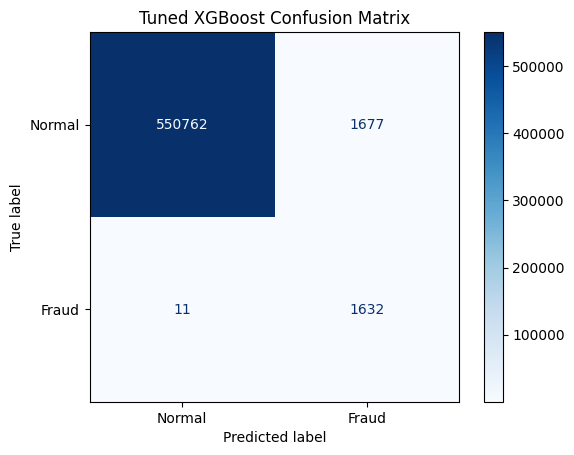

fraud caught: 1632
fraud missed: 11
normal wrongly flagged: 1677
false positive rate: 0.3036 %


In [16]:
cm = confusion_matrix(y_test, y_pred_tuned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Normal', 'Fraud'])
disp.plot(cmap='Blues')
plt.title('Tuned XGBoost Confusion Matrix')
plt.savefig('tuned_confusion_matrix.png', bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print('fraud caught:', tp)
print('fraud missed:', fn)
print('normal wrongly flagged:', fp)
print('false positive rate:', round(fp / (fp + tn) * 100, 4), '%')

## Isolation Forest

XGBoost only catches patterns it learned during training. If a new type of scam appears that looks different to anything in the training data, XGBoost might miss it.

Isolation Forest is unsupervised - it doesn't need fraud labels. It just finds transactions that look unusual compared to everything else. I'm using its anomaly score as an extra input feature for XGBoost rather than using it as a standalone detector.

Training it on training data only then applying to both sets.

In [17]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(
    contamination=0.001,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train_bal)

# add anomaly score as new column
X_train_bal_iso = X_train_bal.copy()
X_train_bal_iso['iso_score'] = iso.decision_function(X_train_bal)

X_test_iso = X_test.copy()
X_test_iso['iso_score'] = iso.decision_function(X_test)

print('iso_score added')
print('score range in test set:', round(X_test_iso['iso_score'].min(), 3), 'to', round(X_test_iso['iso_score'].max(), 3))
print('lower score = more anomalous')

iso_score added
score range in test set: -0.005 to 0.453
lower score = more anomalous


retraining with iso_score included as a feature

In [18]:
FEATURES_ISO = FEATURES + ['iso_score']

best_params_iso = study.best_params.copy()
best_params_iso['random_state'] = 42
best_params_iso['eval_metric'] = 'logloss'
best_params_iso['verbosity'] = 0

final_model = xgb.XGBClassifier(**best_params_iso)
final_model.fit(X_train_bal_iso, y_train_bal)
print('final model trained with iso_score')

final model trained with iso_score


## final results with Isolation Forest

In [19]:
y_pred_final = final_model.predict(X_test_iso)
y_prob_final = final_model.predict_proba(X_test_iso)[:, 1]

print(classification_report(y_test, y_pred_final, target_names=['Normal', 'Fraud']))
print('AUC:', round(roc_auc_score(y_test, y_prob_final), 4))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    552439
       Fraud       0.49      0.99      0.66      1643

    accuracy                           1.00    554082
   macro avg       0.74      0.99      0.83    554082
weighted avg       1.00      1.00      1.00    554082

AUC: 0.9985


full comparison - baseline vs tuned vs tuned with isolation forest

In [20]:
report_final = classification_report(y_test, y_pred_final, output_dict=True)
final = {
    'precision': round(report_final['1']['precision'], 4),
    'recall': round(report_final['1']['recall'], 4),
    'f1': round(report_final['1']['f1-score'], 4),
    'auc': round(roc_auc_score(y_test, y_prob_final), 4)
}

print(f'{"metric":<12} {"baseline":<12} {"tuned":<12} {"tuned+IF"}')
for k in baseline:
    print(f'{k:<12} {baseline[k]:<12} {tuned[k]:<12} {final[k]}')

metric       baseline     tuned        tuned+IF
precision    0.4603       0.4932       0.4898
recall       0.9951       0.9933       0.9909
f1           0.6295       0.6591       0.6555
auc          0.9983       0.9984       0.9985


## save final model

In [21]:
with open('/content/drive/MyDrive/Project/xgb_final.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('/content/drive/MyDrive/Project/iso_forest.pkl', 'wb') as f:
    pickle.dump(iso, f)

X_test_iso.to_csv('/content/drive/MyDrive/Project/X_test_iso.csv', index=False)

print('saved xgb_final.pkl')
print('saved iso_forest.pkl')
print('saved X_test_iso.csv')

saved xgb_final.pkl
saved iso_forest.pkl
saved X_test_iso.csv


## notes

Week 3 done. Optuna ran 50 trials and found better hyperparameters. Then added Isolation Forest anomaly score as an extra feature and retrained.

Next notebook is Week 4 - SHAP explainability. Need to generate a global feature importance plot and a local waterfall plot for one example fraud transaction. These go in the Milestone 2 presentation.